In [1]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv("spam.csv", encoding='latin1')

In [16]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [17]:
df.shape

(5572, 5)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [19]:
df[df['Unnamed: 2'].notnull()]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [20]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [21]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df.rename(columns={'v1' : 'target', 'v2' : 'Message'}, inplace=True)

In [24]:
df.head()

,target,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
df.describe()

,target,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [27]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [29]:
df['target'] = encoder.fit_transform(df['target'])

In [30]:
df.head()

,target,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [32]:
df.isnull().sum()

target     0
Message    0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(403)

In [36]:
df = df.drop_duplicates(keep='first')

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.shape

(5169, 2)

In [39]:
df.value_counts()

target  Message                                                                                                                           
0        &lt;#&gt;  in mca. But not conform.                                                                                                  1
        Thats cool. i liked your photos. You are very sexy!                                                                                   1
        That's good, because I need drugs                                                                                                     1
        That's fine, have him give me a call if he knows what he wants or has any questions                                                   1
        That's fine, I'll bitch at you about it later then                                                                                    1
                                                                                                                                             

In [40]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [41]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

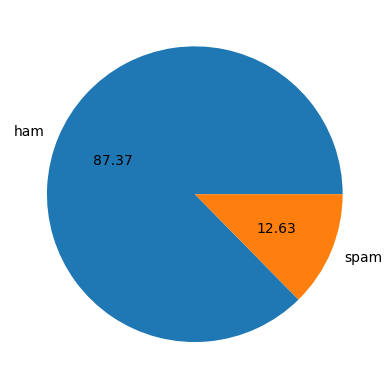

In [46]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show

In [48]:
import nltk

In [56]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lathi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [53]:
df['num_char'] = df['Message'].apply(len)

In [54]:
df.head()

,target,Message,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [69]:
df['num_words'] = df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [67]:
import nltk
nltk.download('punkt_tab', download_dir='C:\\nltk_data')

[nltk_data] Downloading package punkt_tab to C:\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [70]:
df.head()

,target,Message,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [72]:
df['num_sent'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [73]:
df.head()

,target,Message,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [75]:
df[['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [79]:
df[df['target'] == 0][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [80]:
df[df['target'] == 1][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [81]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

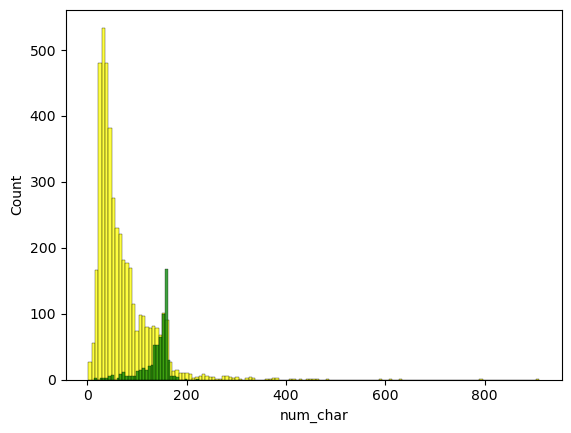

In [86]:
sns.histplot(df[df['target'] == 0]['num_char'],color='yellow')
sns.histplot(df[df['target'] == 1]['num_char'],color='green')

<Axes: xlabel='num_words', ylabel='Count'>

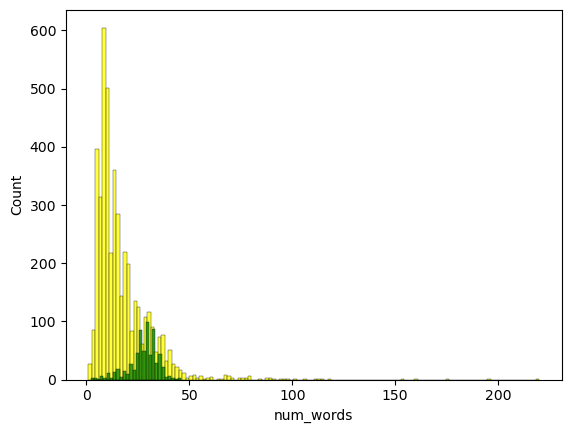

In [87]:
sns.histplot(df[df['target'] == 0]['num_words'],color='yellow')
sns.histplot(df[df['target'] == 1]['num_words'],color='green')

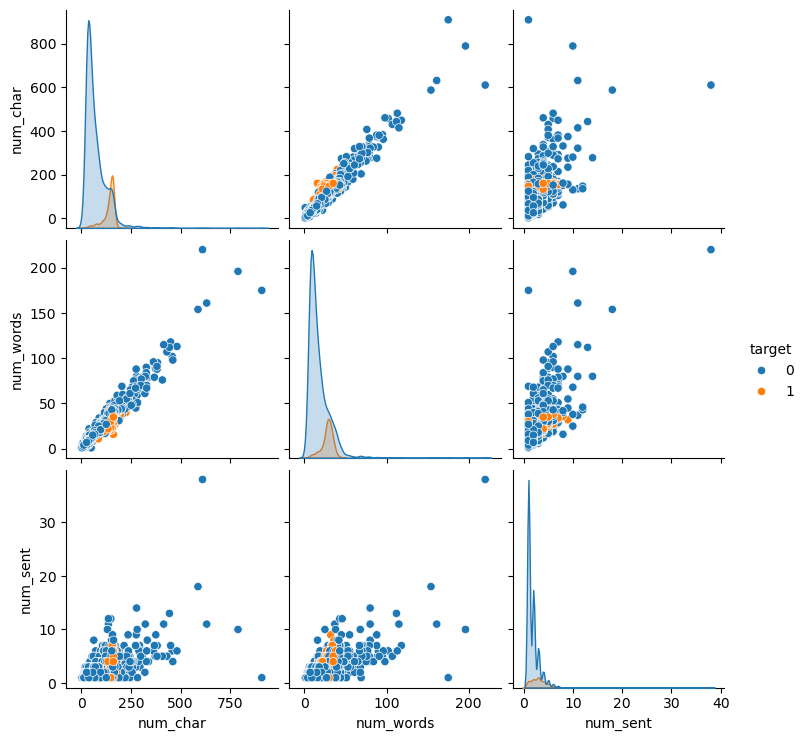

In [90]:
sns.pairplot(df,hue='target')

In [101]:
numeric_columns = df.select_dtypes(include=['number']).columns

<Axes: >

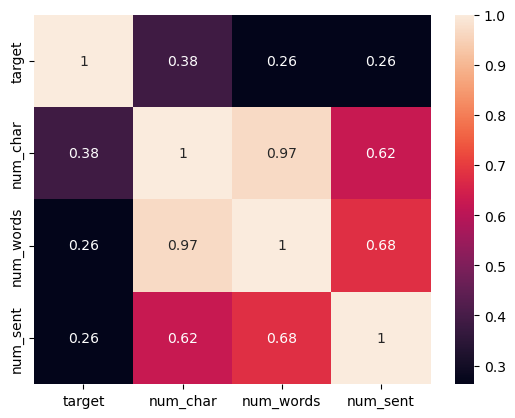

In [104]:
sns.heatmap(df[numeric_columns].corr(),annot=True)

In [122]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()    

    for i in text:
        y.append(ps.stem(i))

        
    return " ".join(y)

In [121]:
import string

In [111]:
from nltk.corpus import stopwords
nltk.download('stopwords', download_dir='C:\\nltk_data')
stopwords.words('english')

[nltk_data] Downloading package stopwords to C:\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [124]:
transform_text('my name is Yash Patel')

'name yash patel'

In [119]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [125]:
transform_text('I have read the book White Nights by fyodor Devoski')

'read book white night fyodor devoski'

In [127]:
df['Message'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [128]:
transform_text(df['Message'][0])

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [130]:
df['transformed_text'] = df['Message'].apply(transform_text)

In [131]:
df.head()

,target,Message,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [143]:
from wordcloud import WordCloud
wc = WordCloud(width=1920,height=1080,min_font_size=10,background_color='white')

In [133]:
!pip install wordcloud

In [146]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

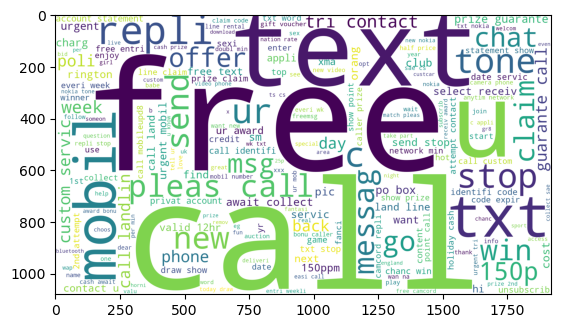

In [147]:
plt.imshow(spam_wc)

In [148]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

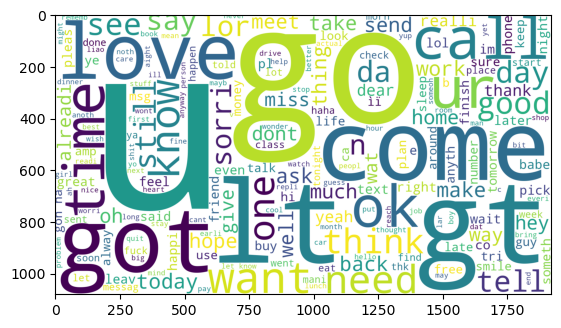

In [149]:
plt.imshow(ham_wc)

In [152]:
spam_corps = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corps.append(word)
        

In [154]:
len(spam_corps)

9939

In [155]:
from collections import Counter

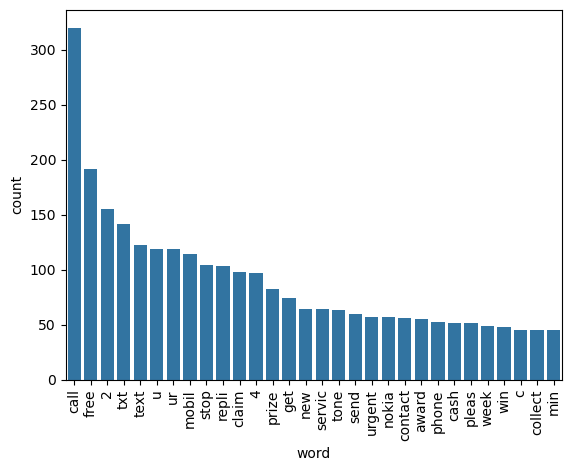

In [162]:
top_words = pd.DataFrame(Counter(spam_corps).most_common(30), columns=['word','count'])

sns.barplot(x='word', y='count', data=top_words)
plt.xticks(rotation=90)
plt.show()

In [164]:
ham_corps = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corps.append(word)
        

In [165]:
len(ham_corps)

35404

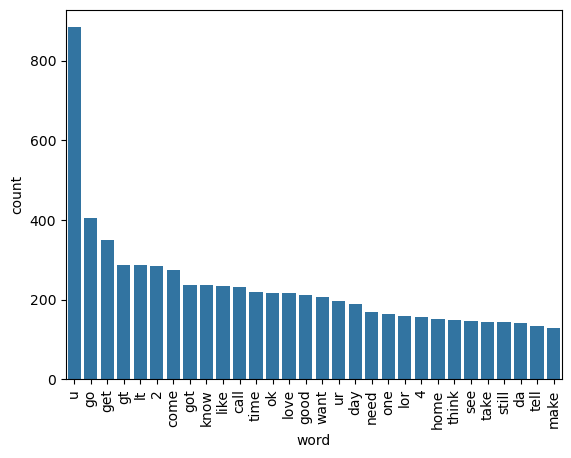

In [166]:
top_words_ham = pd.DataFrame(Counter(ham_corps).most_common(30), columns=['word','count'])

sns.barplot(x='word', y='count', data=top_words_ham)
plt.xticks(rotation=90)
plt.show()

In [224]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [225]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [226]:
X.shape

(5169, 3000)

In [227]:
y = df['target'].values

In [228]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [229]:
from sklearn.model_selection import train_test_split

In [230]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=2)

In [231]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [232]:
gnb = GaussianNB()

In [233]:
mnb = MultinomialNB()
bnb = BernoulliNB()

In [234]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8723404255319149
[[1202  158]
 [  40  151]]
0.4886731391585761


In [235]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9716312056737588
[[1360    0]
 [  44  147]]
1.0


In [236]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9819471308833011
[[1358    2]
 [  26  165]]
0.9880239520958084


In [237]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [213]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 7.6 MB/s eta 0:00:14
   - -------------------------------------- 2.6/101.7 MB 7.9 MB/s eta 0:00:13
   - -------------------------------------- 4.5/101.7 MB 8.0 MB/s eta 0:00:13
   -- ------------------------------------- 6.8/101.7 MB 8.7 MB/s eta 0:00:11
   --- ------------------------------------ 8.9/101.7 MB 9.0 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/101.7 MB 9.4 MB/s eta 0:00:10
   ----- ---------------------------------- 13.6/101.7 MB 9.7 MB/s eta 0:00:10
   ------ --------------------------------- 16.0/101.7 MB 9.9 MB/s eta 0:00:09
   ------- -------------------------------- 18.6/101.7 MB 10.1 MB/s eta 0:00:09
   -------- ------------------------------- 21.2/101.7 MB 10.3 MB/s eta 0:00:08
   --------- ------------------------------ 23.9/101.7 MB 10.5 MB/s eta 0:00:08
   ---------- ----------------------------- 26.0/101.7 MB 10.5

In [238]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [239]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [240]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [241]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9748549323017408, 0.975)

In [242]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9748549323017408
Precision -  0.975
For  KN
Accuracy -  0.9090909090909091
Precision -  1.0
For  NB
Accuracy -  0.9716312056737588
Precision -  1.0
For  DT
Accuracy -  0.9368149580915538
Precision -  0.8251748251748252
For  LR
Accuracy -  0.9522888459058672
Precision -  0.9333333333333333
For  RF
Accuracy -  0.973565441650548
Precision -  0.9746835443037974
For  AdaBoost
Accuracy -  0.9226305609284333
Precision -  0.784
For  BgC
Accuracy -  0.9593810444874274
Precision -  0.8595505617977528
For  ETC
Accuracy -  0.9774339136041263
Precision -  0.9698795180722891
For  GBDT
Accuracy -  0.9509993552546744
Precision -  0.9323308270676691
For  xgb
Accuracy -  0.9677627337201805
Precision -  0.9548387096774194


In [243]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [244]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.909091,1.000000
2,NB,0.971631,1.000000
0,SVC,0.974855,0.975000
5,RF,0.973565,0.974684
8,ETC,0.977434,0.969880
10,xgb,0.967763,0.954839
4,LR,0.952289,0.933333
9,GBDT,0.950999,0.932331
7,BgC,0.959381,0.859551
3,DT,0.936815,0.825175


In [245]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [246]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.909091
1,NB,Accuracy,0.971631
2,SVC,Accuracy,0.974855
3,RF,Accuracy,0.973565
4,ETC,Accuracy,0.977434
5,xgb,Accuracy,0.967763
6,LR,Accuracy,0.952289
7,GBDT,Accuracy,0.950999
8,BgC,Accuracy,0.959381
9,DT,Accuracy,0.936815


In [247]:
import pickle

In [248]:
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))